# Phase 1

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from surprise import Dataset, Reader, SVD, BaselineOnly
from surprise.model_selection import cross_validate, train_test_split

In [29]:
# Read the movie ratings data as CSV
columns = ["userId", "movieId", "categoryId", "reviewId", "movieRating", "reviewDate"]

df = pd.read_csv("../data/movie-ratings.txt", header=None, names=columns)
df.head()

,userId,movieId,categoryId,reviewId,movieRating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [30]:
# Basic statistics: number of users, movies, ratings, and sparsity
n_users = df['userId'].nunique()
n_movies = df['movieId'].nunique()
n_ratings = len(df)

# Sparsity = (total possible ratings - actual ratings) / total possible ratings
total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print("=== Dataset Statistics ===")
print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")
print(f"Sparsity of rating matrix: {sparsity:.4f} ({sparsity*100:.2f}%)")

=== Dataset Statistics ===
Number of users: 17615
Number of movies: 16121
Number of ratings: 72665
Sparsity of rating matrix: 0.9997 (99.97%)


In [31]:
# Basic statistics of the dataframe
print("=== Basic Statistics ===")
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDescriptive statistics:\n{df.describe()}")

=== Basic Statistics ===
Shape: (72665, 6)

Data types:
userId          int64
movieId         int64
categoryId      int64
reviewId        int64
movieRating     int64
reviewDate     object
dtype: object

Missing values:
userId         0
movieId        0
categoryId     0
reviewId       0
movieRating    0
reviewDate     0
dtype: int64

Descriptive statistics:
             userId       movieId    categoryId      reviewId   movieRating
count  72665.000000  72665.000000  72665.000000  72665.000000  72665.000000
mean    4279.437597   8076.878786     12.659300  36333.000000      4.072910
std     4620.200449   4397.176683      4.158915  20976.722992      1.081442
min        1.000000      1.000000      1.000000      1.000000      1.000000
25%      857.000000   4632.000000     11.000000  18167.000000      4.000000
50%     2102.000000   7623.000000     14.000000  36333.000000      4.000000
75%     6568.000000  12105.000000     16.000000  54499.000000      5.000000
max    17615.000000  16121.000000

In [32]:
# Handle missing values by filling with median rating for that movieId
print(f"Missing values before: {df['movieRating'].isnull().sum()}")

# Calculate median rating per movieId
movie_medians = df.groupby('movieId')['movieRating'].median()

# Fill missing values with the median rating for that movieId
def fill_missing_with_median(row):
    if pd.isnull(row['movieRating']):
        return movie_medians.get(row['movieId'], df['movieRating'].median())
    return row['movieRating']

df['movieRating'] = df.apply(fill_missing_with_median, axis=1)

print(f"Missing values after: {df['movieRating'].isnull().sum()}")

Missing values before: 0
Missing values after: 0


/home/emilio/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


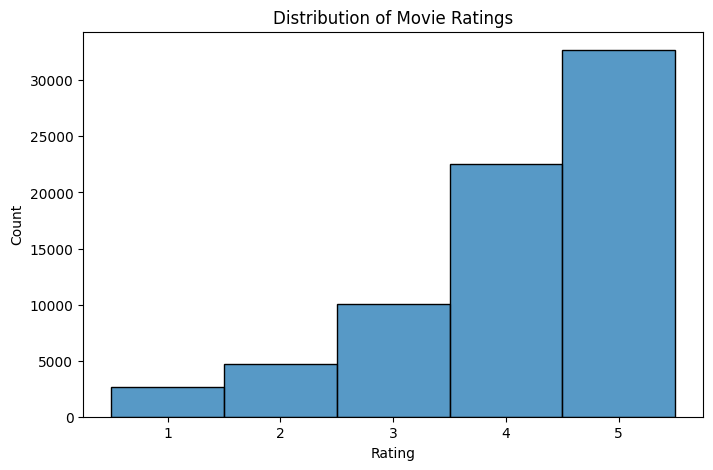

In [33]:
# Histogram of ratings
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['movieRating'], bins=5, discrete=True, edgecolor='black')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

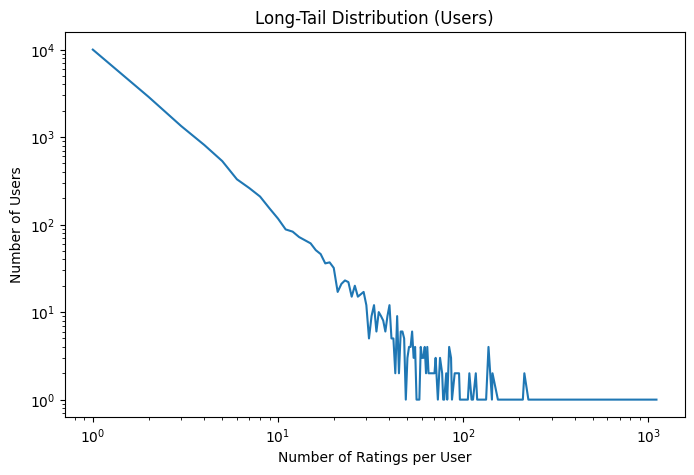

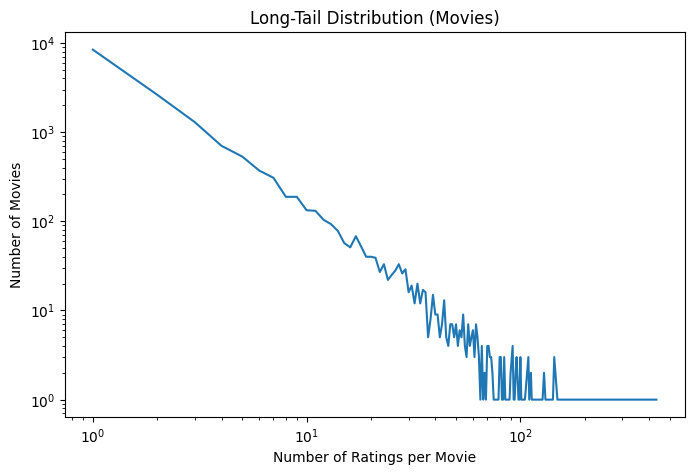

In [34]:
user_counts = df.groupby('userId').size()

# Distribution: how many users have X ratings
user_count_distribution = user_counts.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(user_count_distribution.index, user_count_distribution.values)
plt.title('Long-Tail Distribution (Users)')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.xscale('log')
plt.yscale('log')
plt.show()

movie_counts = df.groupby('movieId').size()

movie_count_distribution = movie_counts.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(movie_count_distribution.index, movie_count_distribution.values)
plt.title('Long-Tail Distribution (Movies)')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')
plt.xscale('log')
plt.yscale('log')
plt.show()